In [8]:
import os
from typing import TypedDict, List, Tuple
from pathlib import Path

from langchain_core.documents import Document
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_community.document_loaders import PyPDFLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, END
from IPython.display import Image, display

In [10]:
groq_api_key = os.getenv("GROQ_API_KEY", "")
if not groq_api_key:
    raise ValueError("Set GROQ_API_KEY in environment variables")

llm = ChatGroq(model="llama-3.3-70b-versatile", groq_api_key=groq_api_key, temperature=0)
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

base_dir = Path(".").resolve()
candidate_dirs = [
    base_dir / "data",
    base_dir / "agentic_rag" / "data",
    Path(__file__).resolve().parent / "data" if "__file__" in globals() else None,
]
docs_dir = next((p for p in candidate_dirs if p is not None and p.exists()), base_dir / "data")
docs_dir.mkdir(parents=True, exist_ok=True)
print(f"Using data folder: {docs_dir}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2793.26it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using data folder: F:\New folder\ai\agentic_rag\data


In [11]:
def load_documents(folder: Path) -> List[Document]:
    all_docs: List[Document] = []
    for path in folder.glob("**/*"):
        if path.is_file() and path.suffix.lower() == ".pdf":
            loader = PyPDFLoader(str(path))
            all_docs.extend(loader.load())
        elif path.is_file() and path.suffix.lower() in {".txt", ".md"}:
            loader = TextLoader(str(path), encoding="utf-8")
            all_docs.extend(loader.load())
    if not all_docs:
        seed_text = "LangGraph enables stateful, multi-step agent workflows with conditional routing."
        all_docs.append(Document(page_content=seed_text, metadata={"source": "seed"}))
    return all_docs


def build_vectorstore(documents: List[Document]) -> FAISS:
    splitter = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=120)
    chunks = splitter.split_documents(documents)
    return FAISS.from_documents(chunks, embeddings)


def _distance_to_confidence(distance: float) -> float:
    # Convert FAISS distance (lower is better) into [0, 1] confidence.
    return 1.0 / (1.0 + max(float(distance), 0.0))


def retrieve_with_scores(query: str, k: int = 4) -> List[Tuple[Document, float]]:
    try:
        docs_and_distances = vectorstore.similarity_search_with_score(query, k=k)
        return [(doc, _distance_to_confidence(distance)) for doc, distance in docs_and_distances]
    except Exception:
        docs = vectorstore.similarity_search(query, k=k)
        return [(doc, 0.0) for doc in docs]


documents = load_documents(docs_dir)
vectorstore = build_vectorstore(documents)
print(f"Loaded {len(documents)} source document pages/chunks before splitting.")

Loaded 23 source document pages/chunks before splitting.


In [17]:
@tool
def wikipedia_search(query: str) -> str:
    """Search Wikipedia and return a concise, grounded summary for a query."""
    import wikipedia

    # Try multiple query variants to reduce false negatives.
    query_variants = [query.strip(), " ".join(query.split()[:8]), " ".join(query.split()[:5])]
    query_variants = [q for i, q in enumerate(query_variants) if q and q not in query_variants[:i]]

    for q in query_variants:
        try:
            # Direct summary with auto-suggest usually works best for general topics.
            return wikipedia.summary(q, sentences=4, auto_suggest=True, redirect=True)
        except wikipedia.exceptions.DisambiguationError as e:
            try:
                option = e.options[0]
                return wikipedia.summary(option, sentences=4, auto_suggest=True, redirect=True)
            except Exception:
                pass
        except Exception:
            pass

        try:
            results = wikipedia.search(q, results=5)
            for title in results:
                try:
                    return wikipedia.summary(title, sentences=4, auto_suggest=False, redirect=True)
                except Exception:
                    continue
        except Exception:
            continue

    return "No reliable Wikipedia summary found for this query."

In [18]:
class AgentState(TypedDict):
    query: str
    rewritten_query: str
    retrieved_docs: List[str]
    retrieval_scores: List[float]
    decision: str
    route_reason: str
    tool_result: str
    final_answer: str


def query_rewriter_node(state: AgentState) -> AgentState:
    prompt = (
        "Rewrite the user query into a short search query for document retrieval. "
        "Keep the original meaning. Return only the rewritten query.\n\n"
        f"User query: {state['query']}"
    )
    rewritten = llm.invoke(
        [
            SystemMessage(content="You rewrite queries for retrieval and never add extra text."),
            HumanMessage(content=prompt),
        ]
    ).content.strip()
    return {**state, "rewritten_query": rewritten or state["query"]}


def retriever_node(state: AgentState) -> AgentState:
    search_query = state.get("rewritten_query") or state["query"]
    docs_and_scores = retrieve_with_scores(search_query, k=4)
    snippets = []
    scores = []
    seen = set()
    for doc, score in docs_and_scores:
        text = doc.page_content.strip()
        key = text[:300]
        if not text or key in seen:
            continue
        seen.add(key)
        snippets.append(text)
        scores.append(float(score))
    return {**state, "retrieved_docs": snippets, "retrieval_scores": scores}


def _token_overlap_ratio(query: str, docs: List[str]) -> float:
    stop = {
        "the", "is", "are", "a", "an", "to", "of", "in", "for", "and", "or", "on", "with", "what", "who", "when", "where",
        "why", "how", "explain", "about", "this", "that", "from", "into", "use", "using", "latest", "current", "recent"
    }
    q_tokens = {t.lower() for t in query.replace("?", " ").replace(",", " ").replace(".", " ").split() if len(t) > 2} - stop
    if not q_tokens or not docs:
        return 0.0
    top_doc_tokens = {t.lower() for t in docs[0].replace("?", " ").replace(",", " ").replace(".", " ").split() if len(t) > 2} - stop
    if not top_doc_tokens:
        return 0.0
    return len(q_tokens.intersection(top_doc_tokens)) / max(len(q_tokens), 1)


def decision_node(state: AgentState) -> AgentState:
    scores = state.get("retrieval_scores", [])
    snippets = state.get("retrieved_docs", [])
    top_score = max(scores) if scores else 0.0
    avg_score = sum(scores) / len(scores) if scores else 0.0
    overlap = _token_overlap_ratio(state["query"], snippets)
    query = state["query"].lower()
    needs_external_context = any(
        phrase in query
        for phrase in ["latest", "current", "recent", "today", "news", "who is", "what is", "when is"]
    )

    if top_score < 0.30 or avg_score < 0.22:
        return {
            **state,
            "decision": "tool",
            "route_reason": f"Low local confidence (top={top_score:.2f}, avg={avg_score:.2f})",
        }

    if overlap < 0.12:
        return {
            **state,
            "decision": "tool",
            "route_reason": f"Low query-context overlap ({overlap:.2f}) despite vector match",
        }

    if needs_external_context and top_score < 0.55:
        return {
            **state,
            "decision": "tool",
            "route_reason": f"Query likely needs external context and local confidence is moderate (top={top_score:.2f})",
        }

    return {
        **state,
        "decision": "answer",
        "route_reason": f"Local retrieval is strong enough (top={top_score:.2f}, avg={avg_score:.2f}, overlap={overlap:.2f})",
    }


def web_tool_node(state: AgentState) -> AgentState:
    search_query = state.get("rewritten_query") or state["query"]
    result = wikipedia_search.invoke(search_query)
    return {**state, "tool_result": result}


def answer_generator_node(state: AgentState) -> AgentState:
    retrieved_context = "\n\n".join(
        f"[Doc {index + 1} | confidence={score:.2f}] {text}"
        for index, (text, score) in enumerate(zip(state.get("retrieved_docs", []), state.get("retrieval_scores", [])))
    )
    tool_context = state.get("tool_result", "")
    prompt = (
        "You are an agentic RAG assistant. Use the supplied evidence to answer the user's question.\n"
        "Rules:\n"
        "- Prefer retrieved documents when they are relevant.\n"
        "- If local docs are weak/insufficient, rely on the web result when available.\n"
        "- If web result is available, provide a medium-length answer in 3 to 5 sentences.\n"
        "- Never output internal diagnostics, route decisions, or confidence values.\n"
        "- Do not repeat the question.\n"
        "- If both local and web evidence are insufficient, say exactly: I could not verify the answer from the available sources.\n\n"
        f"User question: {state['query']}\n\n"
        f"Retrieved documents:\n{retrieved_context or 'None'}\n\n"
        f"Web result:\n{tool_context or 'None'}\n\n"
        "Return a concise, direct answer."
    )
    answer = llm.invoke(
        [
            SystemMessage(content="Answer only from provided evidence. Use 3-5 sentences when evidence exists."),
            HumanMessage(content=prompt),
        ]
    ).content.strip()
    if not answer:
        answer = "I could not verify the answer from the available sources."
    return {**state, "final_answer": answer}


def route_decision(state: AgentState) -> str:
    return state.get("decision", "answer")


workflow = StateGraph(AgentState)
workflow.add_node("query_rewriter", query_rewriter_node)
workflow.add_node("retriever", retriever_node)
workflow.add_node("decision", decision_node)
workflow.add_node("web_tool", web_tool_node)
workflow.add_node("answer_generator", answer_generator_node)

workflow.set_entry_point("query_rewriter")
workflow.add_edge("query_rewriter", "retriever")
workflow.add_edge("retriever", "decision")
workflow.add_conditional_edges(
    "decision",
    route_decision,
    {
        "tool": "web_tool",
        "answer": "answer_generator",
    },
)
workflow.add_edge("web_tool", "answer_generator")
workflow.add_edge("answer_generator", END)

app = workflow.compile()

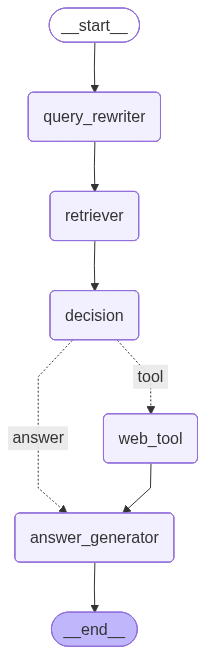

In [6]:
graph_png = app.get_graph().draw_mermaid_png()
display(Image(graph_png))

In [19]:
sample_query = "Who is Alan Turing and why is he important in computing?"
initial_state: AgentState = {
    "query": sample_query,
    "rewritten_query": "",
    "retrieved_docs": [],
    "retrieval_scores": [],
    "decision": "",
    "route_reason": "",
    "tool_result": "",
    "final_answer": "",
}

result_state = app.invoke(initial_state)
print("Decision:", result_state["decision"])
print("Route reason:", result_state["route_reason"])
print(result_state["final_answer"])

Decision: tool
Route reason: Low query-context overlap (0.00) despite vector match
Alan Turing is a British mathematician and reader in mathematics at the University of Manchester, often referred to as the "Father of Computer Science". He is important in computing due to his significant contributions to the field, which are still recognized today through the ACM A. M. Turing Award. This award is given annually for contributions of lasting and major technical importance to computer science and is considered the highest distinction in the field. Turing's work has had a lasting impact on the development of computer science, earning him a prestigious place in the history of the field. His legacy continues to be celebrated through the award that bears his name.
